In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv(
    r"D:\Data solution projects\Log analysis\DA_LOG_ANALYSIS\data\access_logs.csv"
)

In [4]:
data.head(10)

,timestamp,server_id,method,path,status_code,response_time_ms,bytes_sent,user_agent,ip_address,referrer
0,2024-01-01 00:15:12,1,GET,/api/v2/payments/process,201,153,2256,Go-http-client/2.0,107.8.181.20,https://www.bing.com/
1,2024-01-01 00:27:54,2,GET,/docs,304,290,10395,Bingbot/2.0 (+http://www.bing.com/bingbot.htm),167.4.254.26,https://www.google.com/
2,2024-01-01 00:31:42,1,POST,/api/v2/cart,200,201,2452,Go-http-client/2.0,93.47.67.36,https://www.google.com/
3,2024-01-01 00:54:33,2,POST,/static/js/app.js,201,31,2324,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,189.113.25.154,-
4,2024-01-01 01:36:08,2,GET,/contact,200,64,449,curl/8.4.0,168.210.20.247,https://www.google.com/
5,2024-01-01 02:18:04,1,POST,/static/images/logo.png,201,50,5087,curl/8.4.0,43.90.242.32,https://www.google.com/
6,2024-01-01 03:23:09,3,GET,/pricing,200,50,3849,Mozilla/5.0 (Linux; Android 14; Pixel 8) Apple...,147.117.229.138,https://reddit.com/r/webdev
7,2024-01-01 03:40:03,3,PUT,/register,200,121,2298,Go-http-client/2.0,67.60.92.254,-
8,2024-01-01 05:10:57,1,GET,/api/v2/categories,401,339,3680,Bingbot/2.0 (+http://www.bing.com/bingbot.htm),105.23.179.85,https://www.bing.com/
9,2024-01-01 05:11:40,3,POST,/docs,200,10,1095,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,189.143.97.78,-


In [5]:
data.tail(10)

,timestamp,server_id,method,path,status_code,response_time_ms,bytes_sent,user_agent,ip_address,referrer
4990,2024-02-06 12:22:27,3,GET,/login,301,184,15716,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,69.226.93.183,-
4991,2024-02-06 12:24:08,3,GET,/api/v2/shipping/rates,200,44,3483,curl/8.4.0,191.171.34.56,https://www.bing.com/
4992,2024-02-06 12:25:27,1,GET,/api/v2/categories,200,202,978,curl/8.4.0,122.212.177.15,-
4993,2024-02-06 12:25:31,3,GET,/api/v2/wishlist,200,18,61731,Googlebot/2.1 (+http://www.google.com/bot.html),44.43.249.132,-
4994,2024-02-06 12:48:02,2,GET,/api/v2/categories,200,31,31271,Mozilla/5.0 (Macintosh; Intel Mac OS X 14_3_1)...,34.66.200.251,-
4995,2024-02-06 12:57:17,2,PUT,/api/v2/payments/process,200,86,20014,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,141.231.128.247,https://www.bing.com/
4996,2024-02-06 13:04:04,1,GET,/login,200,79,3662,Bingbot/2.0 (+http://www.bing.com/bingbot.htm),130.238.7.78,https://twitter.com/
4997,2024-02-06 13:09:56,1,GET,/api/v2/users/me,401,228,73,PostmanRuntime/7.36.1,213.118.195.73,https://www.bing.com/
4998,2024-02-06 13:13:29,3,GET,/api/v2/shipping/rates,200,543,34020,Bingbot/2.0 (+http://www.bing.com/bingbot.htm),113.139.175.204,https://twitter.com/
4999,2024-02-06 13:19:06,3,GET,/login,200,171,631,Mozilla/5.0 (iPhone; CPU iPhone OS 17_3 like M...,48.74.5.250,https://reddit.com/r/webdev


In [6]:
data.shape

(5000, 10)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   timestamp         5000 non-null   object
 1   server_id         5000 non-null   int64 
 2   method            5000 non-null   object
 3   path              5000 non-null   object
 4   status_code       5000 non-null   int64 
 5   response_time_ms  5000 non-null   int64 
 6   bytes_sent        5000 non-null   int64 
 7   user_agent        5000 non-null   object
 8   ip_address        5000 non-null   object
 9   referrer          5000 non-null   object
dtypes: int64(4), object(6)
memory usage: 390.8+ KB


In [8]:
data["status_code"].unique()

array([201, 304, 200, 401, 301, 404, 400, 500, 503, 403], dtype=int64)

In [9]:
count200 = data[data["status_code"] == 400].shape
count200

(192, 10)

In [10]:
for x in data["status_code"].unique():
    print("nbre of status code", x, ":", data[data["status_code"] == x].shape[0])

nbre of status code 201 : 245
nbre of status code 304 : 292
nbre of status code 200 : 3638
nbre of status code 401 : 156
nbre of status code 301 : 118
nbre of status code 404 : 197
nbre of status code 400 : 192
nbre of status code 500 : 85
nbre of status code 503 : 25
nbre of status code 403 : 52


In [11]:
for x in data["status_code"].unique():
    print(f"Percentage of status code {x}: {data[data['status_code'] == x].shape[0] / data.shape[0] * 100:.2f} %")

Percentage of status code 201: 4.90 %
Percentage of status code 304: 5.84 %
Percentage of status code 200: 72.76 %
Percentage of status code 401: 3.12 %
Percentage of status code 301: 2.36 %
Percentage of status code 404: 3.94 %
Percentage of status code 400: 3.84 %
Percentage of status code 500: 1.70 %
Percentage of status code 503: 0.50 %
Percentage of status code 403: 1.04 %


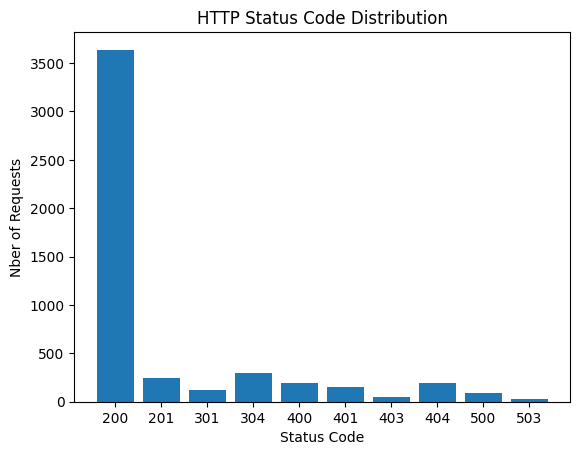

In [12]:
counts = data["status_code"].value_counts().sort_index()

plt.bar(counts.index.astype(str), counts.values)
plt.title("HTTP Status Code Distribution")
plt.xlabel("Status Code")
plt.ylabel("Nber of Requests")
plt.show()

In [13]:
len(data["path"].unique())

33

In [14]:
data["path"].unique()

array(['/api/v2/payments/process', '/docs', '/api/v2/cart',
       '/static/js/app.js', '/contact', '/static/images/logo.png',
       '/pricing', '/register', '/api/v2/categories', '/blog',
       '/api/v2/users/register', '/sitemap.xml', '/login', '/favicon.ico',
       '/', '/about', '/healthz', '/api/v2/search', '/api/v2/reviews',
       '/api/v2/orders', '/api/v2/orders/{id}', '/robots.txt',
       '/.well-known/security.txt', '/api/v2/wishlist', '/blog/{slug}',
       '/api/v2/products/{id}', '/api/v2/cart/checkout',
       '/api/v2/products', '/api/v2/shipping/rates',
       '/static/css/main.css', '/docs/{page}', '/api/v2/users/me',
       '/api/v2/users/login'], dtype=object)

In [15]:
for x in data["path"].unique():
    print("nbre of visited", x, ":", data[data["path"] == x].shape[0])

nbre of visited /api/v2/payments/process : 139
nbre of visited /docs : 152
nbre of visited /api/v2/cart : 151
nbre of visited /static/js/app.js : 166
nbre of visited /contact : 166
nbre of visited /static/images/logo.png : 166
nbre of visited /pricing : 132
nbre of visited /register : 143
nbre of visited /api/v2/categories : 158
nbre of visited /blog : 149
nbre of visited /api/v2/users/register : 155
nbre of visited /sitemap.xml : 164
nbre of visited /login : 159
nbre of visited /favicon.ico : 150
nbre of visited / : 149
nbre of visited /about : 191
nbre of visited /healthz : 158
nbre of visited /api/v2/search : 140
nbre of visited /api/v2/reviews : 140
nbre of visited /api/v2/orders : 136
nbre of visited /api/v2/orders/{id} : 150
nbre of visited /robots.txt : 154
nbre of visited /.well-known/security.txt : 137
nbre of visited /api/v2/wishlist : 167
nbre of visited /blog/{slug} : 151
nbre of visited /api/v2/products/{id} : 147
nbre of visited /api/v2/cart/checkout : 145
nbre of visited

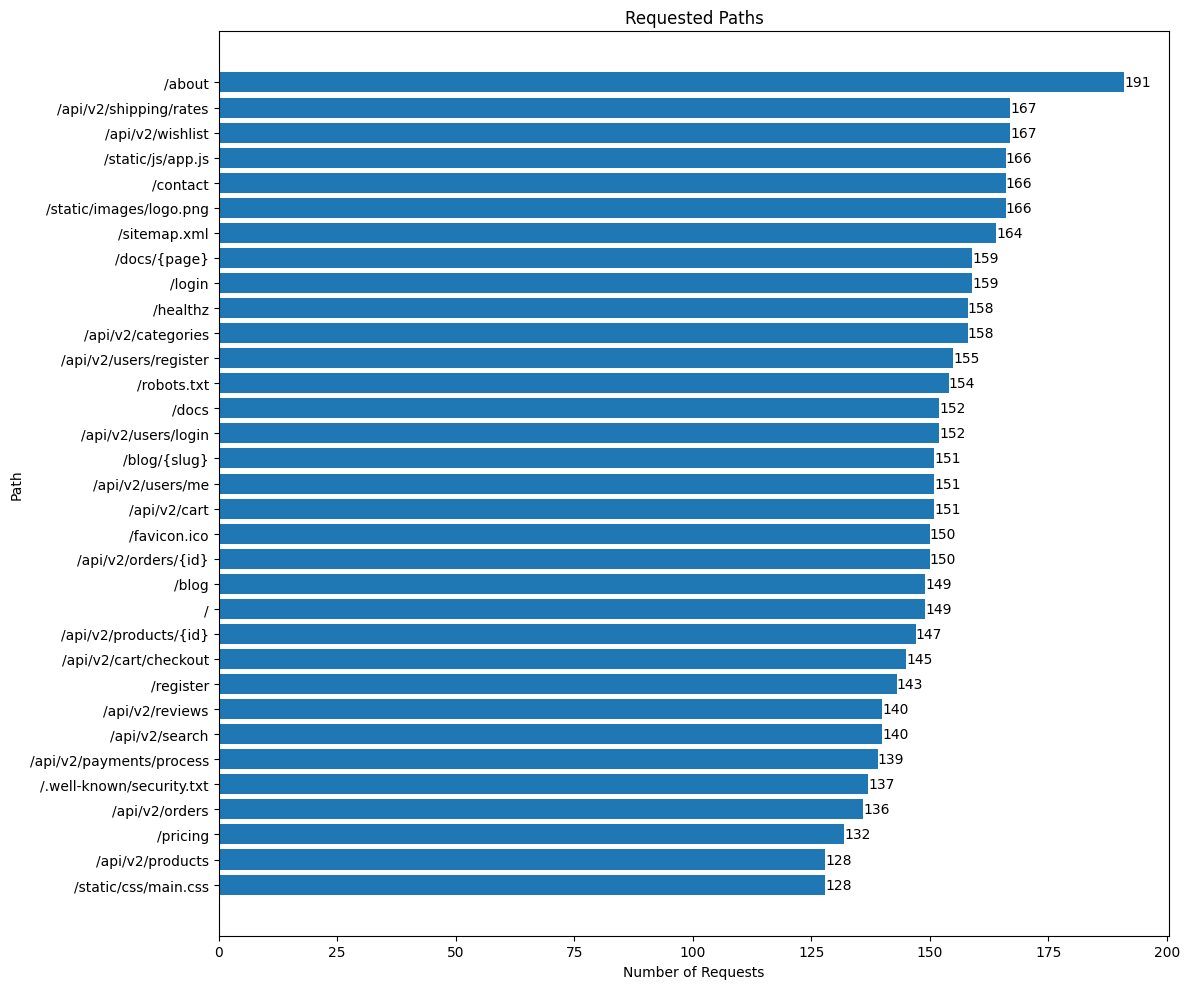

In [16]:
counts = data["path"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(12, 10))
bars = plt.barh(counts.index.astype(str), counts.values)

plt.bar_label(bars)

plt.title("Requested Paths")
plt.xlabel("Number of Requests")
plt.ylabel("Path")

plt.tight_layout()
plt.show()

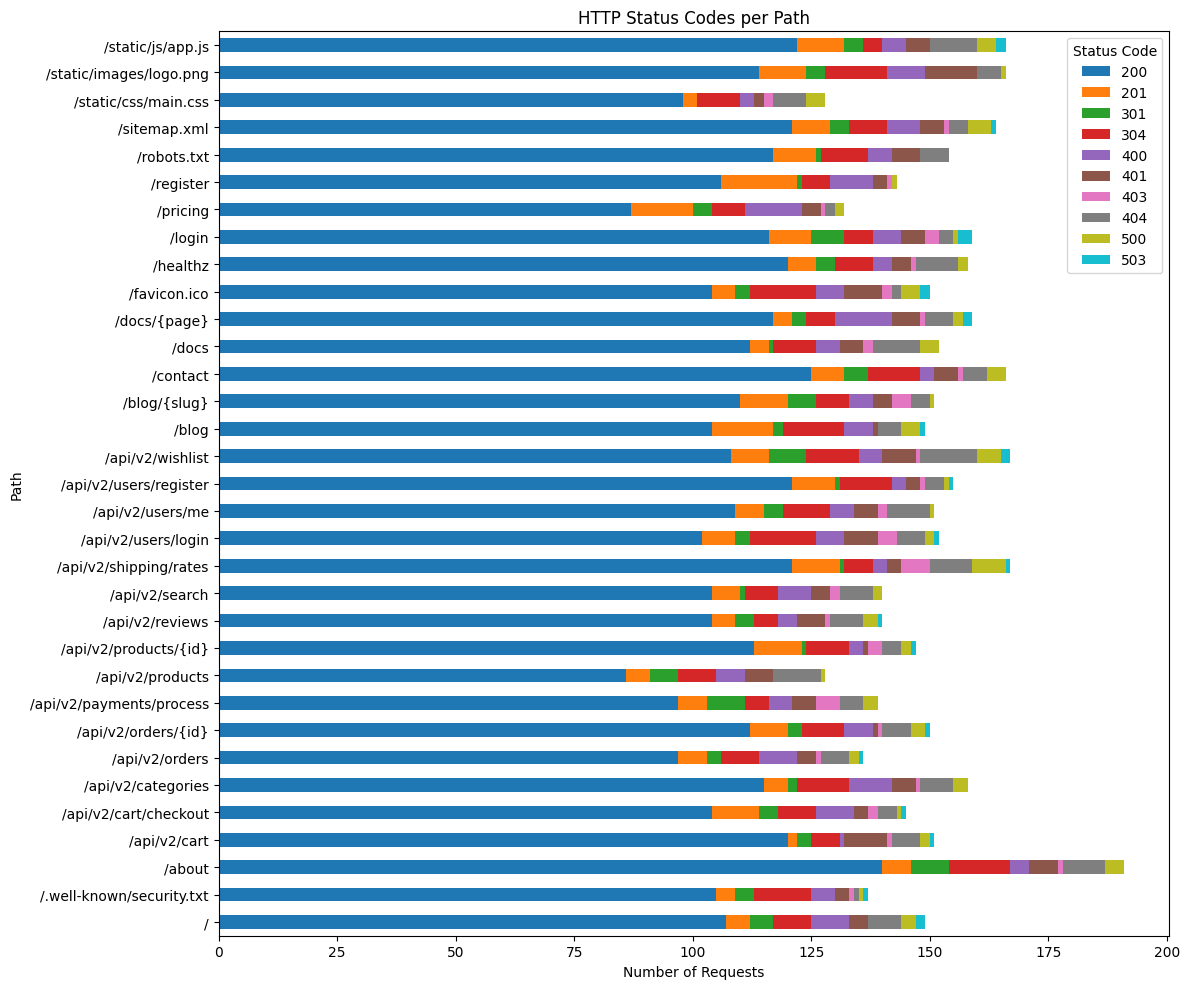

In [17]:
status_by_path = (data.groupby(["path", "status_code"]).size().unstack(fill_value=0))

status_by_path.plot(kind="barh",stacked=True,figsize=(12, 10))

plt.title("HTTP Status Codes per Path")
plt.xlabel("Number of Requests")
plt.ylabel("Path")
plt.legend(title="Status Code")

plt.tight_layout()
plt.show()

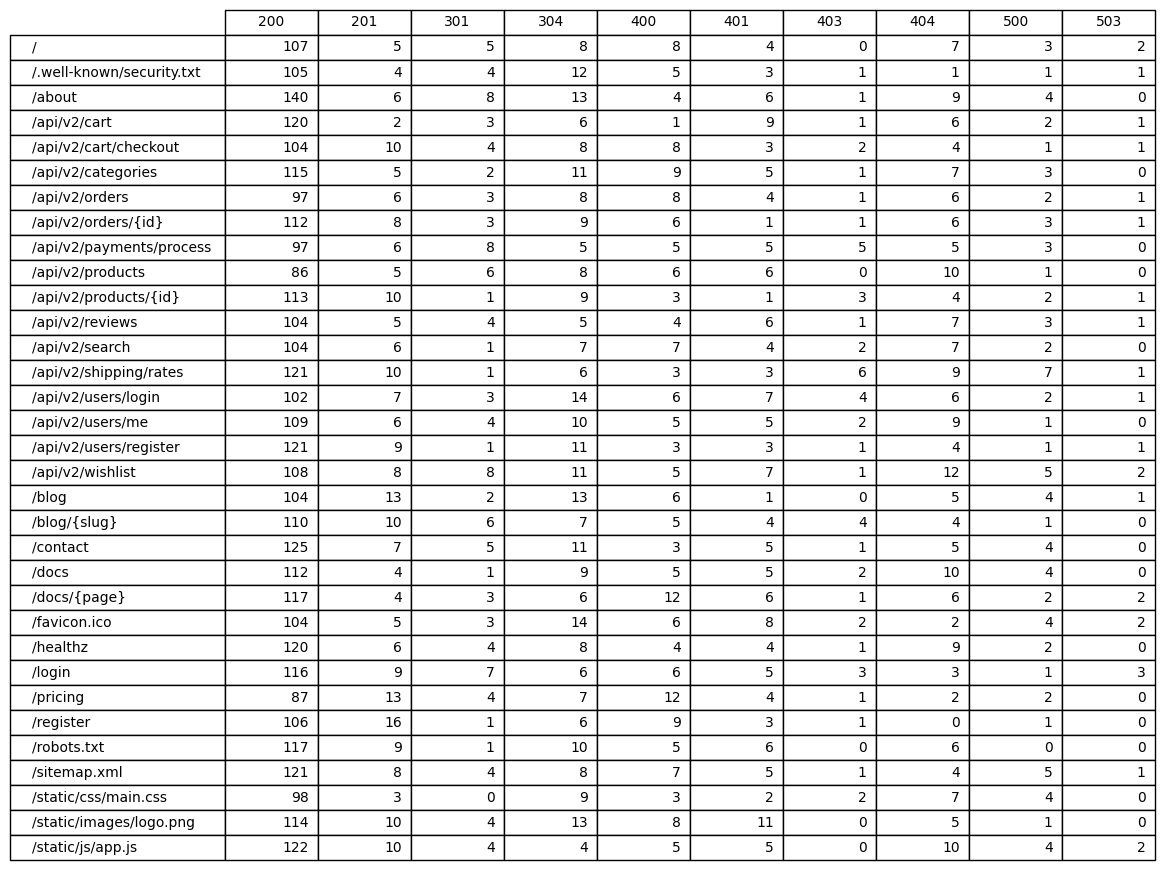

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis("off")

table = ax.table(cellText=status_by_path.values,rowLabels=status_by_path.index,colLabels=status_by_path.columns,loc="center")

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)


plt.show()

Index(['timestamp', 'server_id', 'method', 'path', 'status_code',
       'response_time_ms', 'bytes_sent', 'user_agent', 'ip_address',
       'referrer'],
      dtype='object')

In [19]:
print("mean of the time taken to serve the request:", data["response_time_ms"].mean(),"ms")

mean of the time taken to serve the request: 180.7296 ms


In [20]:
Q1 = data["response_time_ms"].quantile(0.25)
Q3 = data["response_time_ms"].quantile(0.75)
IQR = Q3 - Q1
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 40.0
Q3: 199.25
IQR: 159.25


In [21]:
lowerBound = Q1 - 1.5 * IQR
upperBound = Q3 + 1.5 * IQR
print("Lower Bound:", lowerBound)
print("Upper Bound:", upperBound)

Lower Bound: -198.875
Upper Bound: 438.125


In [22]:
outliers = data[(data["response_time_ms"] < lowerBound) | (data["response_time_ms"] > upperBound)]
outliers

,timestamp,server_id,method,path,status_code,response_time_ms,bytes_sent,user_agent,ip_address,referrer
28,2024-01-01 08:28:59,1,GET,/api/v2/users/register,200,2026,10085,Bingbot/2.0 (+http://www.bing.com/bingbot.htm),57.186.130.82,https://www.bing.com/
29,2024-01-01 08:29:51,1,GET,/api/v2/reviews,200,468,10596,Mozilla/5.0 (iPhone; CPU iPhone OS 17_3 like M...,4.6.198.2,https://www.bing.com/
30,2024-01-01 08:30:02,1,GET,/login,200,486,510,PostmanRuntime/7.36.1,44.174.113.80,https://www.bing.com/
45,2024-01-01 09:45:11,1,GET,/pricing,200,755,1711,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,134.60.142.102,https://reddit.com/r/webdev
48,2024-01-01 10:05:26,1,POST,/api/v2/categories,200,793,4805,Mozilla/5.0 (Linux; Android 14; Pixel 8) Apple...,126.92.26.112,-
...,...,...,...,...,...,...,...,...,...,...
4949,2024-02-06 07:31:16,1,PUT,/login,200,571,9164,Mozilla/5.0 (iPhone; CPU iPhone OS 17_3 like M...,119.248.67.0,https://www.bing.com/
4950,2024-02-06 08:06:31,1,POST,/api/v2/wishlist,200,755,3009,Mozilla/5.0 (Linux; Android 14; Pixel 8) Apple...,34.225.3.20,https://twitter.com/
4978,2024-02-06 11:20:07,1,GET,/static/images/logo.png,200,622,6561,Bingbot/2.0 (+http://www.bing.com/bingbot.htm),111.208.36.198,-
4984,2024-02-06 11:41:24,1,POST,/blog/{slug},200,589,6731,Bingbot/2.0 (+http://www.bing.com/bingbot.htm),22.205.102.174,https://www.google.com/


In [23]:
outliers.size

4440

In [24]:
outliersGrouped = outliers.groupby("path").size().sort_values(ascending=False)
outliersGrouped

path
/api/v2/users/register       23
/static/js/app.js            18
/api/v2/categories           17
/login                       17
/healthz                     17
/api/v2/orders               16
/register                    16
/.well-known/security.txt    16
/blog/{slug}                 15
/robots.txt                  15
/contact                     15
/api/v2/shipping/rates       15
/api/v2/users/login          15
/                            14
/api/v2/users/me             14
/pricing                     13
/docs/{page}                 13
/about                       13
/api/v2/cart                 13
/api/v2/payments/process     13
/api/v2/search               12
/api/v2/reviews              12
/api/v2/cart/checkout        12
/docs                        11
/favicon.ico                 11
/api/v2/products             11
/api/v2/orders/{id}          11
/sitemap.xml                 11
/static/images/logo.png      11
/api/v2/wishlist             11
/api/v2/products/{id}         9
/bl

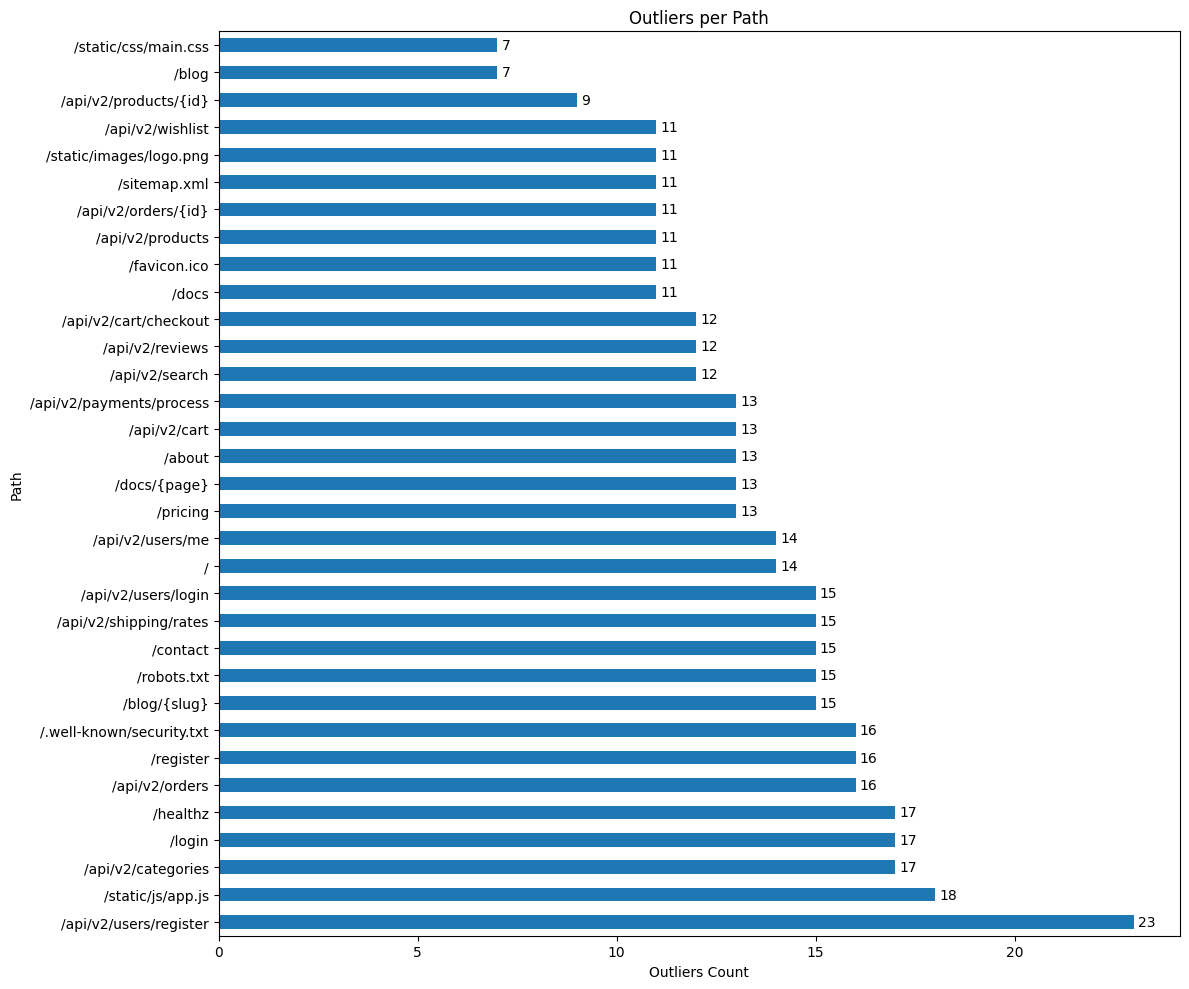

In [25]:
ax = outliersGrouped.plot(kind="barh", figsize=(12, 10))

ax.bar_label(ax.containers[0], padding=3)

plt.title("Outliers per Path")
plt.xlabel("Outliers Count")
plt.ylabel("Path")

plt.tight_layout()
plt.show()

In [26]:
outliersGrouped = outliers.groupby("status_code").size().sort_values(ascending=False)
outliersGrouped


status_code
200    322
304     29
201     26
400     19
401     15
404     14
301     10
500      5
403      3
503      1
dtype: int64

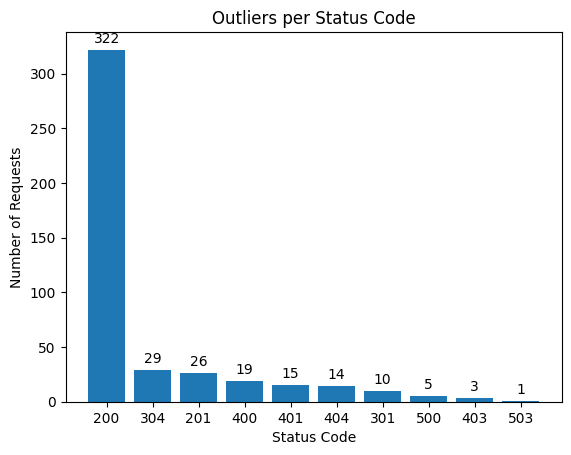

In [27]:
bars = plt.bar(outliersGrouped.index.astype(str), outliersGrouped.values)

plt.bar_label(bars, padding=3)

plt.title("Outliers per Status Code")
plt.xlabel("Status Code")
plt.ylabel("Number of Requests")

plt.show()

In [28]:
data["method"].unique()

array(['GET', 'POST', 'PUT', 'DELETE', 'PATCH'], dtype=object)

In [29]:
data["method"].value_counts()

method
GET       3360
POST      1013
PUT        378
DELETE     158
PATCH       91
Name: count, dtype: int64

In [30]:
dataPost = data[data["method"] == "POST"]
dataPost["path"].unique()

array(['/api/v2/cart', '/static/js/app.js', '/static/images/logo.png',
       '/docs', '/blog', '/favicon.ico', '/', '/api/v2/categories',
       '/about', '/api/v2/orders/{id}', '/api/v2/products/{id}',
       '/pricing', '/login', '/healthz', '/api/v2/search', '/contact',
       '/api/v2/wishlist', '/api/v2/cart/checkout', '/api/v2/users/login',
       '/register', '/robots.txt', '/api/v2/shipping/rates',
       '/api/v2/payments/process', '/api/v2/products', '/blog/{slug}',
       '/.well-known/security.txt', '/api/v2/reviews',
       '/api/v2/users/register', '/sitemap.xml', '/api/v2/orders',
       '/docs/{page}', '/api/v2/users/me', '/static/css/main.css'],
      dtype=object)

In [31]:
len(dataPost["path"].unique())

33

In [32]:
dataPostGrouped = dataPost.groupby("path").size().sort_values(ascending=False)

In [33]:
dataPostGrouped

path
/api/v2/categories           43
/static/images/logo.png      40
/docs                        37
/contact                     36
/api/v2/users/register       34
/api/v2/reviews              34
/.well-known/security.txt    34
/static/js/app.js            34
/api/v2/orders/{id}          34
/about                       34
/healthz                     33
/api/v2/shipping/rates       33
/api/v2/users/login          33
/api/v2/users/me             33
/blog/{slug}                 33
/api/v2/products/{id}        32
/api/v2/wishlist             31
/api/v2/orders               31
/login                       31
/favicon.ico                 30
/docs/{page}                 29
/register                    28
/pricing                     28
/blog                        27
/api/v2/cart/checkout        27
/api/v2/payments/process     26
/sitemap.xml                 25
/api/v2/search               25
/                            25
/robots.txt                  24
/api/v2/cart                 23
/ap

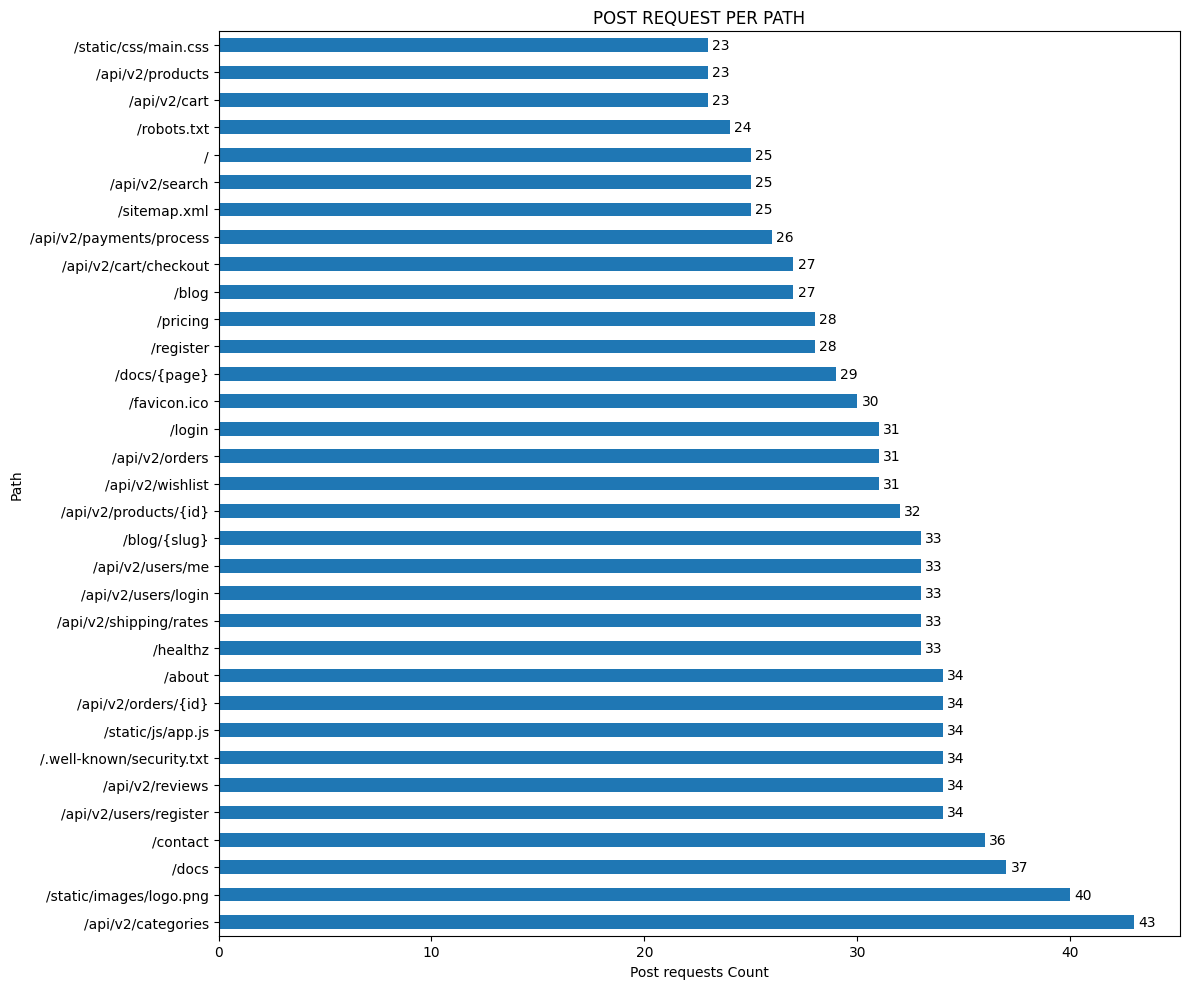

In [34]:
ax = dataPostGrouped.plot(kind="barh", figsize=(12, 10))

ax.bar_label(ax.containers[0], padding=3)

plt.title("POST REQUEST PER PATH")
plt.xlabel("Post requests Count")
plt.ylabel("Path")

plt.tight_layout()
plt.show()

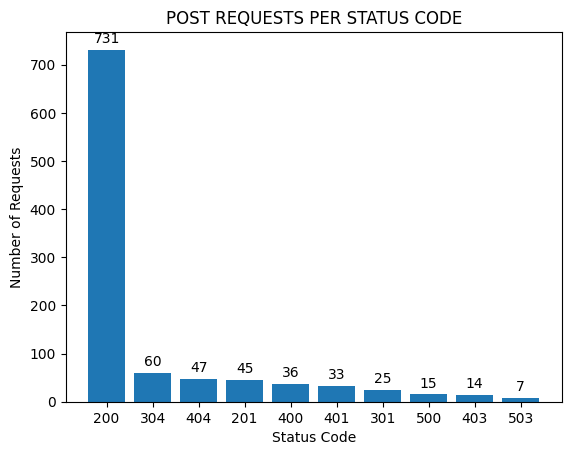

In [35]:
dataPostGrouped = dataPost.groupby("status_code").size().sort_values(ascending=False)
bars = plt.bar(dataPostGrouped.index.astype(str), dataPostGrouped.values)

plt.bar_label(bars, padding=3)

plt.title("POST REQUESTS PER STATUS CODE")
plt.xlabel("Status Code")
plt.ylabel("Number of Requests")

plt.show()

In [36]:
len(data["ip_address"].unique())

3162

In [37]:
data["ip_address"].mode()

0    183.149.15.230
Name: ip_address, dtype: object

In [38]:
dataIPMOSTRepeated = data[data["ip_address"] == "183.149.15.230"]

In [39]:
dataIPMOSTRepeated

,timestamp,server_id,method,path,status_code,response_time_ms,bytes_sent,user_agent,ip_address,referrer
2496,2024-01-18 11:13:49,1,POST,/robots.txt,200,115,2769,Googlebot/2.1 (+http://www.google.com/bot.html),183.149.15.230,-
2629,2024-01-19 10:39:41,2,GET,/api/v2/payments/process,200,25,7340,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,183.149.15.230,https://www.google.com/
3268,2024-01-24 10:06:35,3,GET,/healthz,200,90,2424,Mozilla/5.0 (Macintosh; Intel Mac OS X 14_3_1)...,183.149.15.230,https://reddit.com/r/webdev
3756,2024-01-27 15:54:39,3,GET,/healthz,200,633,6544,Mozilla/5.0 (Macintosh; Intel Mac OS X 14_3_1)...,183.149.15.230,https://twitter.com/
3981,2024-01-29 15:36:13,3,GET,/api/v2/categories,400,411,57836,Bingbot/2.0 (+http://www.bing.com/bingbot.htm),183.149.15.230,https://reddit.com/r/webdev
4194,2024-01-31 09:12:13,3,GET,/api/v2/reviews,200,133,1656,Googlebot/2.1 (+http://www.google.com/bot.html),183.149.15.230,https://reddit.com/r/webdev


In [40]:
dataERROR = data[(data["status_code"] >= 400) & (data["status_code"] < 500)]
dataERROR

,timestamp,server_id,method,path,status_code,response_time_ms,bytes_sent,user_agent,ip_address,referrer
8,2024-01-01 05:10:57,1,GET,/api/v2/categories,401,339,3680,Bingbot/2.0 (+http://www.bing.com/bingbot.htm),105.23.179.85,https://www.bing.com/
18,2024-01-01 07:01:32,2,GET,/contact,404,9,1904,Go-http-client/2.0,1.112.233.62,https://www.google.com/
20,2024-01-01 07:21:18,1,POST,/static/images/logo.png,400,25,2337,PostmanRuntime/7.36.1,63.51.24.247,https://www.google.com/
23,2024-01-01 07:57:37,1,GET,/api/v2/payments/process,404,223,2545,PostmanRuntime/7.36.1,174.14.70.84,https://www.google.com/
24,2024-01-01 08:11:32,3,GET,/api/v2/cart,404,44,5779,Mozilla/5.0 (Macintosh; Intel Mac OS X 14_3_1)...,91.221.123.162,https://www.bing.com/
...,...,...,...,...,...,...,...,...,...,...
4945,2024-02-06 07:14:42,1,GET,/api/v2/wishlist,400,266,6588,Mozilla/5.0 (Linux; Android 14; Pixel 8) Apple...,23.61.96.113,https://twitter.com/
4954,2024-02-06 08:32:51,3,GET,/favicon.ico,400,363,6376,Mozilla/5.0 (Linux; Android 14; Pixel 8) Apple...,152.6.22.197,https://www.bing.com/
4956,2024-02-06 09:03:57,1,POST,/api/v2/users/me,404,45,6268,Bingbot/2.0 (+http://www.bing.com/bingbot.htm),81.153.220.179,https://www.bing.com/
4969,2024-02-06 10:10:44,1,GET,/api/v2/wishlist,400,57,820,Mozilla/5.0 (iPhone; CPU iPhone OS 17_3 like M...,152.64.19.255,https://reddit.com/r/webdev


In [41]:
dataERROR["status_code"].value_counts().sort_index()

status_code
400    192
401    156
403     52
404    197
Name: count, dtype: int64

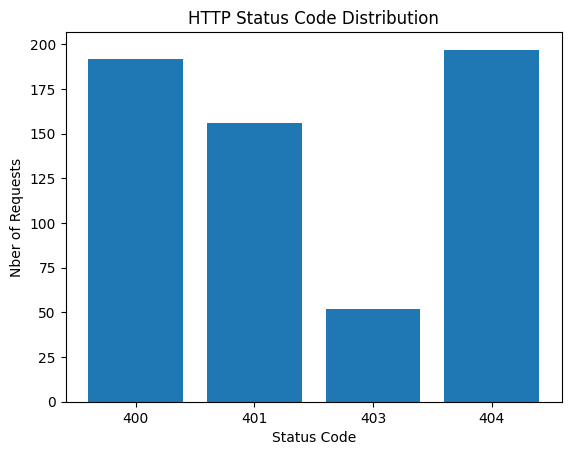

In [42]:
counts = dataERROR["status_code"].value_counts().sort_index()
bars = plt.bar(counts.index.astype(str), counts.values)

plt.title("HTTP Status Code Distribution")
plt.xlabel("Status Code")
plt.ylabel("Nber of Requests")
plt.show()

In [43]:
dataERRORGrouped = dataERROR.groupby("path").size().sort_values(ascending=False)

In [44]:
dataERRORGrouped

path
/docs/{page}                 25
/api/v2/wishlist             25
/static/images/logo.png      24
/api/v2/users/login          23
/api/v2/categories           22
/docs                        22
/api/v2/products             22
/api/v2/users/me             21
/api/v2/shipping/rates       21
/static/js/app.js            20
/about                       20
/api/v2/payments/process     20
/api/v2/search               20
/pricing                     19
/                            19
/api/v2/orders               19
/api/v2/reviews              18
/favicon.ico                 18
/healthz                     18
/blog/{slug}                 17
/login                       17
/api/v2/cart/checkout        17
/robots.txt                  17
/sitemap.xml                 17
/api/v2/cart                 17
/contact                     14
/api/v2/orders/{id}          14
/static/css/main.css         14
/register                    13
/blog                        12
/api/v2/products/{id}        11
/ap

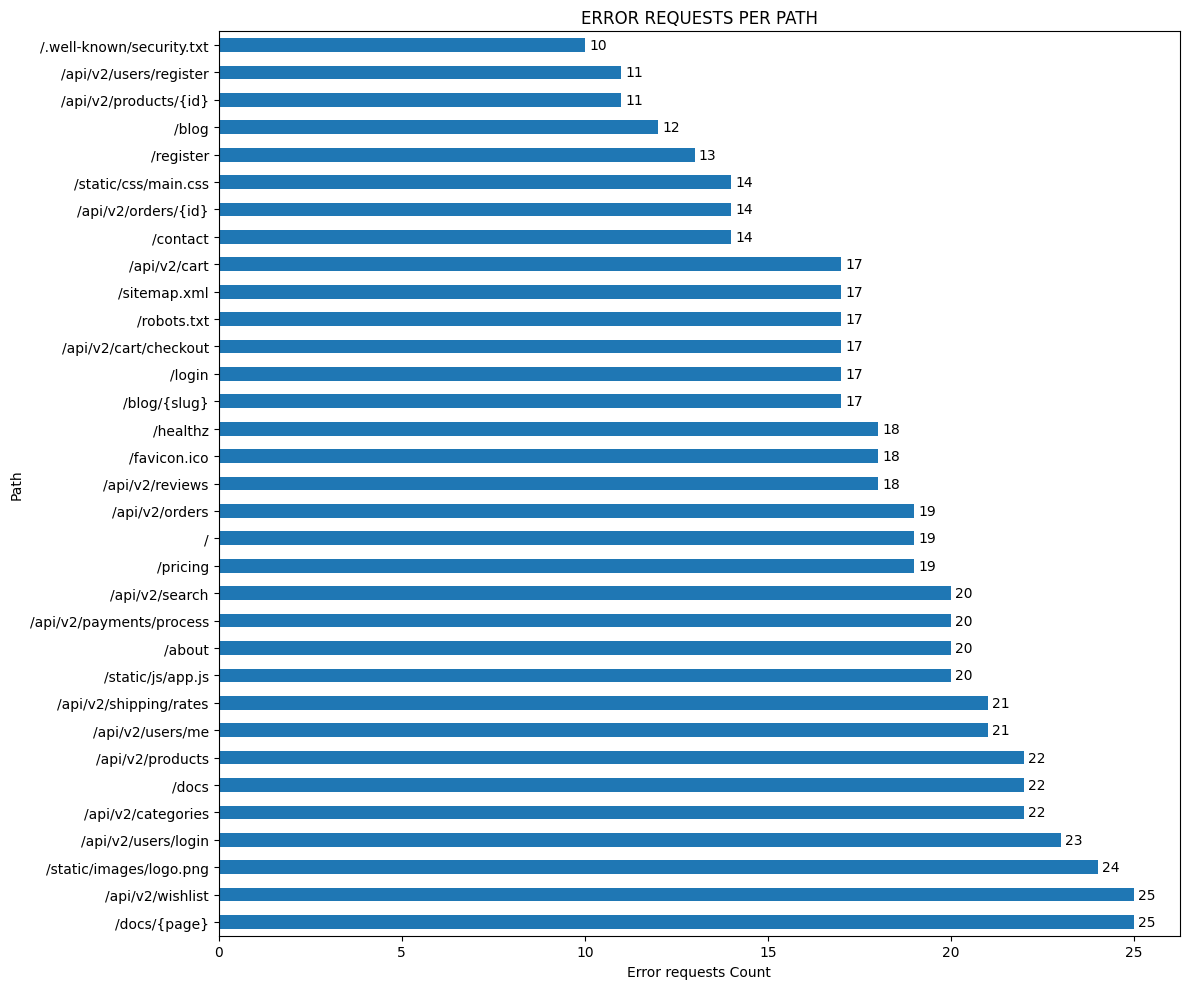

In [45]:
ax = dataERRORGrouped.plot(kind="barh", figsize=(12, 10))

ax.bar_label(ax.containers[0], padding=3)

plt.title("ERROR REQUESTS PER PATH")
plt.xlabel("Error requests Count")
plt.ylabel("Path")

plt.tight_layout()
plt.show()

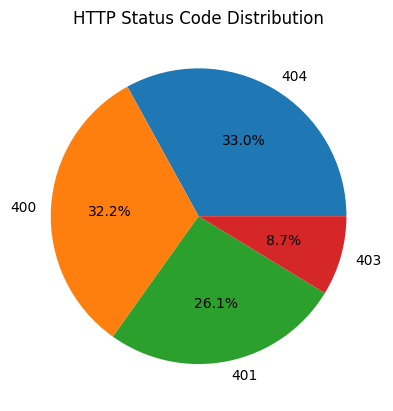

In [46]:
dataERRORGrouped = dataERROR.groupby("status_code").size().sort_values(ascending=False)

plt.pie(dataERRORGrouped.values, labels=dataERRORGrouped.index.astype(str), autopct="%1.1f%%")
plt.title("HTTP Status Code Distribution")
plt.show()

In [47]:
dataERROR

,timestamp,server_id,method,path,status_code,response_time_ms,bytes_sent,user_agent,ip_address,referrer
8,2024-01-01 05:10:57,1,GET,/api/v2/categories,401,339,3680,Bingbot/2.0 (+http://www.bing.com/bingbot.htm),105.23.179.85,https://www.bing.com/
18,2024-01-01 07:01:32,2,GET,/contact,404,9,1904,Go-http-client/2.0,1.112.233.62,https://www.google.com/
20,2024-01-01 07:21:18,1,POST,/static/images/logo.png,400,25,2337,PostmanRuntime/7.36.1,63.51.24.247,https://www.google.com/
23,2024-01-01 07:57:37,1,GET,/api/v2/payments/process,404,223,2545,PostmanRuntime/7.36.1,174.14.70.84,https://www.google.com/
24,2024-01-01 08:11:32,3,GET,/api/v2/cart,404,44,5779,Mozilla/5.0 (Macintosh; Intel Mac OS X 14_3_1)...,91.221.123.162,https://www.bing.com/
...,...,...,...,...,...,...,...,...,...,...
4945,2024-02-06 07:14:42,1,GET,/api/v2/wishlist,400,266,6588,Mozilla/5.0 (Linux; Android 14; Pixel 8) Apple...,23.61.96.113,https://twitter.com/
4954,2024-02-06 08:32:51,3,GET,/favicon.ico,400,363,6376,Mozilla/5.0 (Linux; Android 14; Pixel 8) Apple...,152.6.22.197,https://www.bing.com/
4956,2024-02-06 09:03:57,1,POST,/api/v2/users/me,404,45,6268,Bingbot/2.0 (+http://www.bing.com/bingbot.htm),81.153.220.179,https://www.bing.com/
4969,2024-02-06 10:10:44,1,GET,/api/v2/wishlist,400,57,820,Mozilla/5.0 (iPhone; CPU iPhone OS 17_3 like M...,152.64.19.255,https://reddit.com/r/webdev


In [48]:
len(dataERROR["ip_address"].unique())

564

In [49]:
for code in dataERROR["status_code"].unique():
    print(f"Most repeated IP for status code {code}: {dataERROR[dataERROR['status_code'] == code]['ip_address'].mode()[0]}")

Most repeated IP for status code 401: 101.169.215.28
Most repeated IP for status code 404: 13.165.120.96
Most repeated IP for status code 400: 113.209.33.218
Most repeated IP for status code 403: 101.11.56.55


In [50]:
dataMOSTREPEATEDIP_ERROR = dataERROR[dataERROR["ip_address"] == dataERROR["ip_address"].mode()[0]]
dataMOSTREPEATEDIP_ERROR

,timestamp,server_id,method,path,status_code,response_time_ms,bytes_sent,user_agent,ip_address,referrer
41,2024-01-01 09:32:16,2,GET,/blog/{slug},400,122,1038,Mozilla/5.0 (Linux; Android 14; Pixel 8) Apple...,152.153.39.58,https://www.google.com/
1308,2024-01-09 20:37:35,2,PUT,/static/css/main.css,404,393,47247,Go-http-client/2.0,152.153.39.58,-
1987,2024-01-15 09:17:50,2,GET,/pricing,400,61,29649,PostmanRuntime/7.36.1,152.153.39.58,https://twitter.com/


In [51]:
data4xCODE = data[data["status_code"].isin([401, 403])]

In [52]:
data4xCODE

,timestamp,server_id,method,path,status_code,response_time_ms,bytes_sent,user_agent,ip_address,referrer
8,2024-01-01 05:10:57,1,GET,/api/v2/categories,401,339,3680,Bingbot/2.0 (+http://www.bing.com/bingbot.htm),105.23.179.85,https://www.bing.com/
46,2024-01-01 09:45:49,3,POST,/static/js/app.js,401,4,439,Bingbot/2.0 (+http://www.bing.com/bingbot.htm),182.131.222.129,https://www.google.com/
58,2024-01-01 10:41:04,2,POST,/login,401,45,99183,Go-http-client/2.0,33.64.2.241,https://reddit.com/r/webdev
84,2024-01-01 12:46:54,2,GET,/blog/{slug},401,86,1075,curl/8.4.0,204.24.90.41,-
89,2024-01-01 13:11:48,1,GET,/docs,401,68,2447,curl/8.4.0,220.139.228.231,https://www.bing.com/
...,...,...,...,...,...,...,...,...,...,...
4851,2024-02-05 11:54:03,2,GET,/api/v2/cart,401,611,1437,Mozilla/5.0 (iPhone; CPU iPhone OS 17_3 like M...,95.76.227.40,-
4900,2024-02-05 17:37:47,1,POST,/api/v2/cart,401,52,6264,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,7.175.80.129,https://www.bing.com/
4918,2024-02-05 20:45:04,1,POST,/api/v2/search,401,786,2375,Bingbot/2.0 (+http://www.bing.com/bingbot.htm),194.242.13.119,https://reddit.com/r/webdev
4937,2024-02-06 05:44:23,3,GET,/healthz,403,40,1523,curl/8.4.0,73.80.206.55,https://reddit.com/r/webdev


In [53]:
top10_ips = data4xCODE["ip_address"].value_counts().head(10)

In [54]:
top10_ips

ip_address
189.87.109.136    2
7.198.222.111     2
105.23.179.85     1
165.168.83.205    1
165.248.67.102    1
98.138.196.155    1
101.169.215.28    1
69.108.9.76       1
148.27.150.166    1
174.22.119.122    1
Name: count, dtype: int64

In [55]:
dataServersInfo = pd.read_csv(
    r"D:\Data solution projects\Log analysis\DA_LOG_ANALYSIS\data\servers.csv"
)

In [56]:
dataServersInfo

,id,name,region,role
0,1,web-prod-01,us-east-1,api
1,2,web-prod-02,us-east-1,api
2,3,web-prod-03,us-west-2,static


In [57]:
data["server_id"].unique()

array([1, 2, 3], dtype=int64)

In [58]:
data["server_id"].shape

(5000,)

In [60]:
dataServersInfo.rename(columns={"id": "server_id"}, inplace=True)

In [61]:
dataServersInfo

,server_id,name,region,role
0,1,web-prod-01,us-east-1,api
1,2,web-prod-02,us-east-1,api
2,3,web-prod-03,us-west-2,static


In [62]:
dataMerged = pd.merge(data, dataServersInfo, on="server_id", how="inner")

In [65]:
dataMerged.columns

Index(['timestamp', 'server_id', 'method', 'path', 'status_code',
       'response_time_ms', 'bytes_sent', 'user_agent', 'ip_address',
       'referrer', 'name', 'region', 'role'],
      dtype='object')

In [67]:
dataToUse=dataMerged[["timestamp", "ip_address", "method", "path", "status_code", "response_time_ms", "server_id", "name", "region","role"]]

In [68]:
dataToUse

,timestamp,ip_address,method,path,status_code,response_time_ms,server_id,name,region,role
0,2024-01-01 00:15:12,107.8.181.20,GET,/api/v2/payments/process,201,153,1,web-prod-01,us-east-1,api
1,2024-01-01 00:27:54,167.4.254.26,GET,/docs,304,290,2,web-prod-02,us-east-1,api
2,2024-01-01 00:31:42,93.47.67.36,POST,/api/v2/cart,200,201,1,web-prod-01,us-east-1,api
3,2024-01-01 00:54:33,189.113.25.154,POST,/static/js/app.js,201,31,2,web-prod-02,us-east-1,api
4,2024-01-01 01:36:08,168.210.20.247,GET,/contact,200,64,2,web-prod-02,us-east-1,api
...,...,...,...,...,...,...,...,...,...,...
4995,2024-02-06 12:57:17,141.231.128.247,PUT,/api/v2/payments/process,200,86,2,web-prod-02,us-east-1,api
4996,2024-02-06 13:04:04,130.238.7.78,GET,/login,200,79,1,web-prod-01,us-east-1,api
4997,2024-02-06 13:09:56,213.118.195.73,GET,/api/v2/users/me,401,228,1,web-prod-01,us-east-1,api
4998,2024-02-06 13:13:29,113.139.175.204,GET,/api/v2/shipping/rates,200,543,3,web-prod-03,us-west-2,static


In [70]:
dataServerName = dataToUse.groupby("name").size().sort_values(ascending=False)
dataServerName

name
web-prod-03    1688
web-prod-01    1670
web-prod-02    1642
dtype: int64

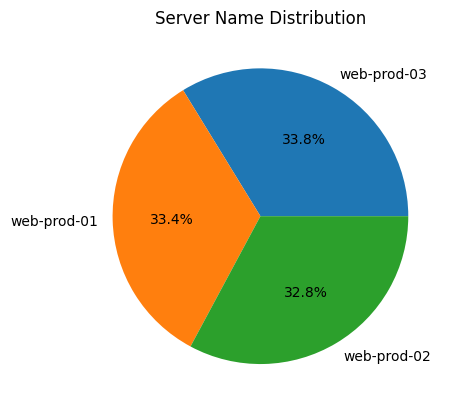

In [74]:
plt.pie(dataServerName.values, labels=dataServerName.index.astype(str), autopct="%1.1f%%")
plt.title("Server Name Distribution")
plt.show()

In [76]:
dataStatusPerServer = (dataToUse.groupby(["name", "status_code"]).size().unstack(fill_value=0))

dataStatusPerServer

status_code,200,201,301,304,400,401,403,404,500,503
name,,,,,,,,,,
web-prod-01,1218,89,45,93,62,45,16,67,28,7
web-prod-02,1183,76,42,91,60,59,17,74,35,5
web-prod-03,1237,80,31,108,70,52,19,56,22,13


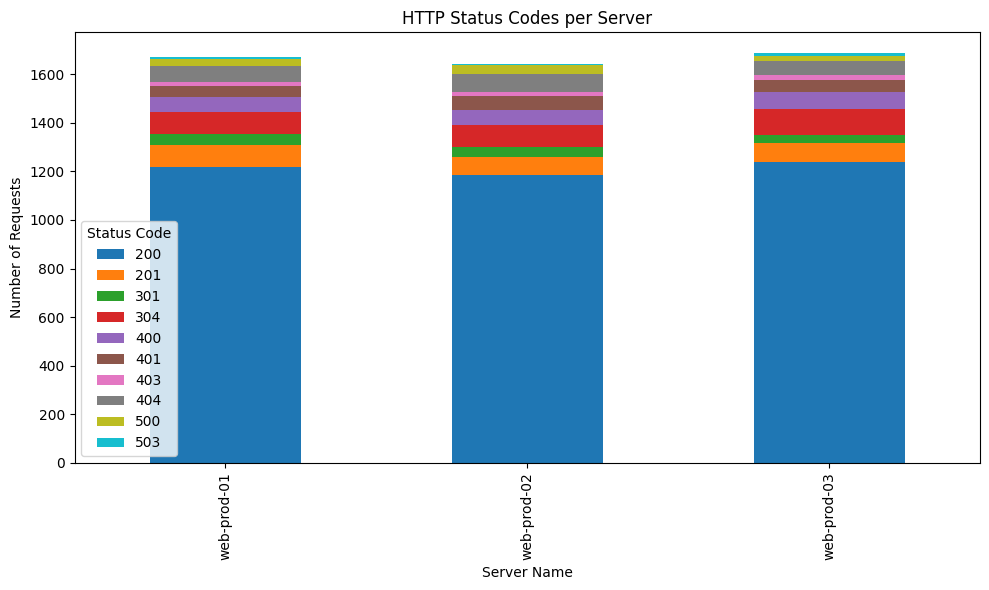

In [77]:
dataStatusPerServer.plot(kind="bar", stacked=True, figsize=(10, 6))

plt.title("HTTP Status Codes per Server")
plt.xlabel("Server Name")
plt.ylabel("Number of Requests")
plt.legend(title="Status Code")
plt.tight_layout()
plt.show()